# Section 5.5: Test 4 - Category Recognition

This section notebook uses the authoritative Test 4 results generated by `5-test4-category-recognition.ipynb` rather than re-running a parallel scoring workflow.

**Primary data source:** `results/test4_category_recognition/test4_results.csv`
**Raw response reference:** `ai_responses/test4_category_recognition/all_responses.json`

## Goal

Provide reproducible integrity checks and publication-ready summary outputs for Section 5.5 while maintaining a single scoring implementation.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use(Path('setups/plotstyles.mplstyle'))

# Global colormaps / palettes — from setups/viz_styles.py
from setups.viz_styles import (
    WHITE_SKY_CMAP, 
    SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP, 
    SIMILARITY_HIST_COLOR, 
    THRESHOLD_COLOR, 
    TEXT_COLOR,
    MODEL_VISIBLE_COLORS,
)


In [3]:
canonical_dir = Path('results/test4_category_recognition')
section_output_dir = Path('results/test4')
section_output_dir.mkdir(parents=True, exist_ok=True)

canonical_results_file = canonical_dir / 'test4_results.csv'
raw_responses_file = Path('ai_responses/test4_category_recognition/all_responses.json')

print('Section 5.5 initialized (imported-results mode).')
print(f'Test 4 results file: {canonical_results_file}')

Section 5.5 initialized (imported-results mode).
Test 4 results file: results/test4_category_recognition/test4_results.csv


In [4]:
if not canonical_results_file.exists():
    raise FileNotFoundError(
        f'Test 4 results file not found: {canonical_results_file}. '
        'Run 5-test4-category-recognition.ipynb to generate it.'
    )

results_df = pd.read_csv(canonical_results_file)

required_columns = [
    'Sample_ID', 'Model', 'Scenario_Type', 'Parsed_OK',
    'Categories_Identified', 'Contested_Categories',
    'Category_Mistakes', 'Missed_Distinctions',
    'Distinction_Score', 'Identification_Score',
    'Alternative_Score', 'Total_Score',
    'Training_Derived', 'Similarity',
]
missing_columns = [c for c in required_columns if c not in results_df.columns]
if missing_columns:
    raise ValueError(f'Results file is missing required columns: {missing_columns}')

print(f'Loaded rows: {len(results_df)}')
print(f"Unique models: {results_df['Model'].nunique()}")
print('Scenario distribution:')
print(results_df['Scenario_Type'].value_counts(dropna=False).to_string())

display(results_df.head())

Loaded rows: 168
Unique models: 7
Scenario distribution:
Scenario_Type
standard    168


,Sample_ID,Model,Scenario_Type,Parsed_OK,Categories_Identified,Contested_Categories,Category_Mistakes,Missed_Distinctions,Distinction_Score,Identification_Score,Alternative_Score,Total_Score,Training_Derived,Similarity
0,4,deepseek-v3.2,standard,True,8,3,3,4,3,3,5,11,True,0.456459
1,12,mistral-large,standard,True,8,4,3,4,4,2,5,11,True,0.455141
2,14,deepseek-v3.2,standard,True,9,4,3,4,5,2,5,12,True,0.451348
3,4,llama-3.3-70b-instruct,standard,True,4,3,2,2,0,1,4,5,True,0.474563
4,20,deepseek-v3.2,standard,True,7,4,3,4,4,3,5,12,True,0.484309


## 1. Data Integrity Checks

In [5]:
if not raw_responses_file.exists():
    raise FileNotFoundError(f'Raw responses file not found: {raw_responses_file}')

with open(raw_responses_file, 'r', encoding='utf-8') as f:
    raw_responses = json.load(f)

raw_count = len(raw_responses)
results_count = len(results_df)
parsed_ok_count = int(results_df['Parsed_OK'].fillna(False).sum())
parsed_ok_rate = parsed_ok_count / results_count if results_count else np.nan

integrity_summary = {
    'raw_response_rows': raw_count,
    'results_rows': results_count,
    'row_count_match': raw_count == results_count,
    'parsed_ok_count': parsed_ok_count,
    'parsed_ok_rate': float(parsed_ok_rate),
    'models': sorted(results_df['Model'].dropna().unique().tolist()),
    'scenario_types': sorted(results_df['Scenario_Type'].dropna().unique().tolist()),
}

print('INTEGRITY SUMMARY')
print('=' * 60)
for key, value in integrity_summary.items():
    print(f'{key}: {value}')

if raw_count != results_count:
    print('\nWARNING: Row counts differ between raw responses and scored results.')
else:
    print('\nRow counts are aligned between raw responses and scored results.')

INTEGRITY SUMMARY
raw_response_rows: 168
results_rows: 168
row_count_match: True
parsed_ok_count: 168
parsed_ok_rate: 1.0
models: ['claude-3.7-sonnet', 'deepseek-v3.2', 'gemini-3.1-pro-preview', 'gpt-5.2', 'llama-3.3-70b-instruct', 'mistral-large', 'perplexity-sonar-pro']
scenario_types: ['standard']

Row counts are aligned between raw responses and scored results.


## 2. Descriptive Statistics (Imported Test 4 Scores)

In [6]:
score_columns = ['Distinction_Score', 'Identification_Score', 'Alternative_Score', 'Total_Score']

overall_summary = results_df[score_columns].agg(['mean', 'std', 'min', 'max']).round(3)
model_summary = (
    results_df.groupby('Model', as_index=False)[score_columns]
    .mean()
    .sort_values('Total_Score', ascending=False)
    .reset_index(drop=True)
)

scenario_summary = (
    results_df.groupby('Scenario_Type', dropna=False)[score_columns]
    .mean()
    .round(3)
)

print('OVERALL SCORE SUMMARY')
display(overall_summary)

print('MODEL-LEVEL MEAN SCORES')
display(model_summary)

print('SCENARIO-LEVEL MEAN SCORES')
display(scenario_summary)

OVERALL SCORE SUMMARY


,Distinction_Score,Identification_Score,Alternative_Score,Total_Score
mean,2.649,2.845,3.375,8.869
std,1.624,0.862,1.167,2.761
min,0.000,1.000,1.000,4.000
max,5.000,5.000,5.000,14.000


MODEL-LEVEL MEAN SCORES


,Model,Distinction_Score,Identification_Score,Alternative_Score,Total_Score
0,gpt-5.2,5.000000,4.083333,3.291667,12.375000
1,mistral-large,3.958333,3.041667,4.375000,11.375000
2,deepseek-v3.2,3.583333,3.041667,3.750000,10.375000
3,claude-3.7-sonnet,2.333333,2.750000,3.833333,8.916667
4,gemini-3.1-pro-preview,1.500000,2.666667,2.750000,6.916667
5,perplexity-sonar-pro,1.791667,2.750000,1.875000,6.416667
6,llama-3.3-70b-instruct,0.375000,1.583333,3.750000,5.708333


SCENARIO-LEVEL MEAN SCORES


,Distinction_Score,Identification_Score,Alternative_Score,Total_Score
Scenario_Type,,,,
standard,2.649,2.845,3.375,8.869


## 3. Visual Analysis (Imported Test 4 Outputs)

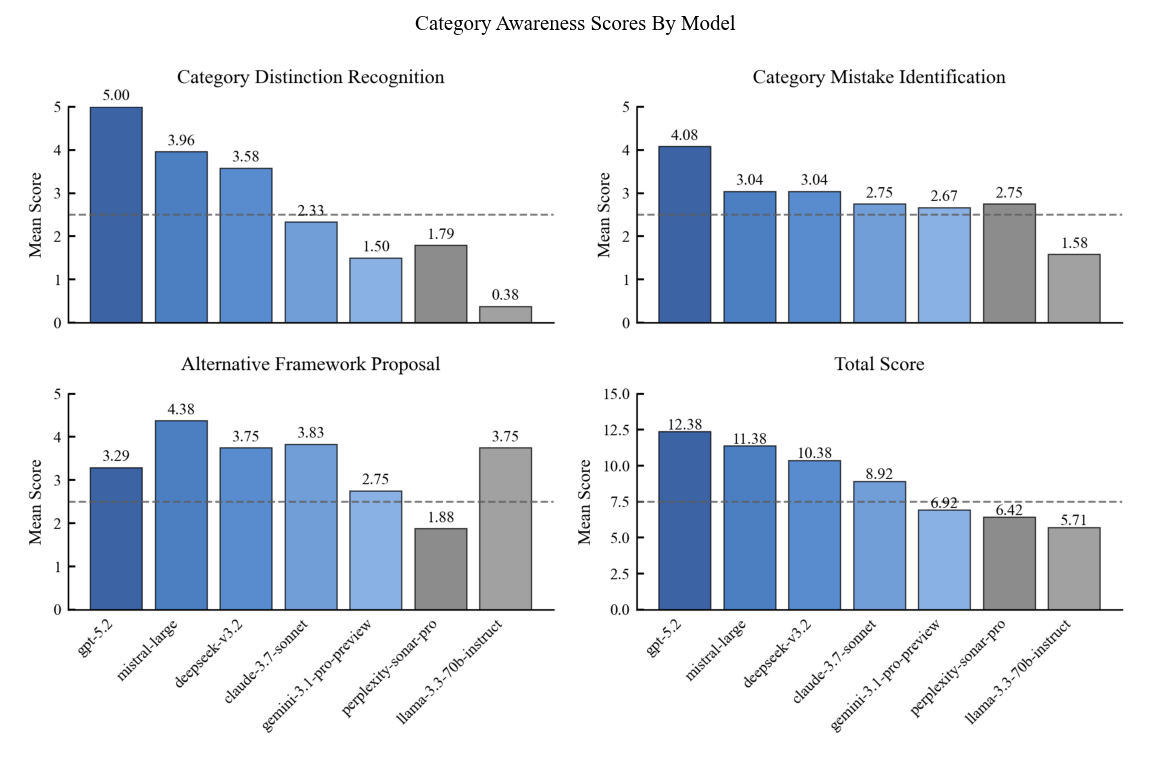

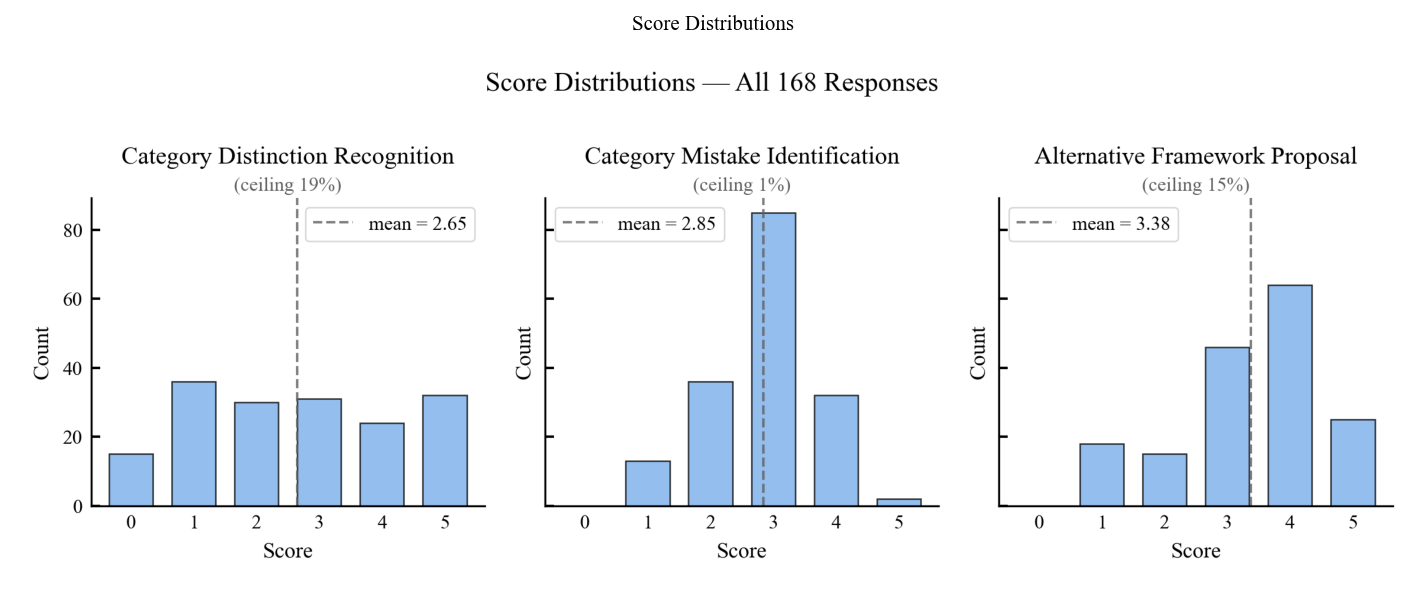

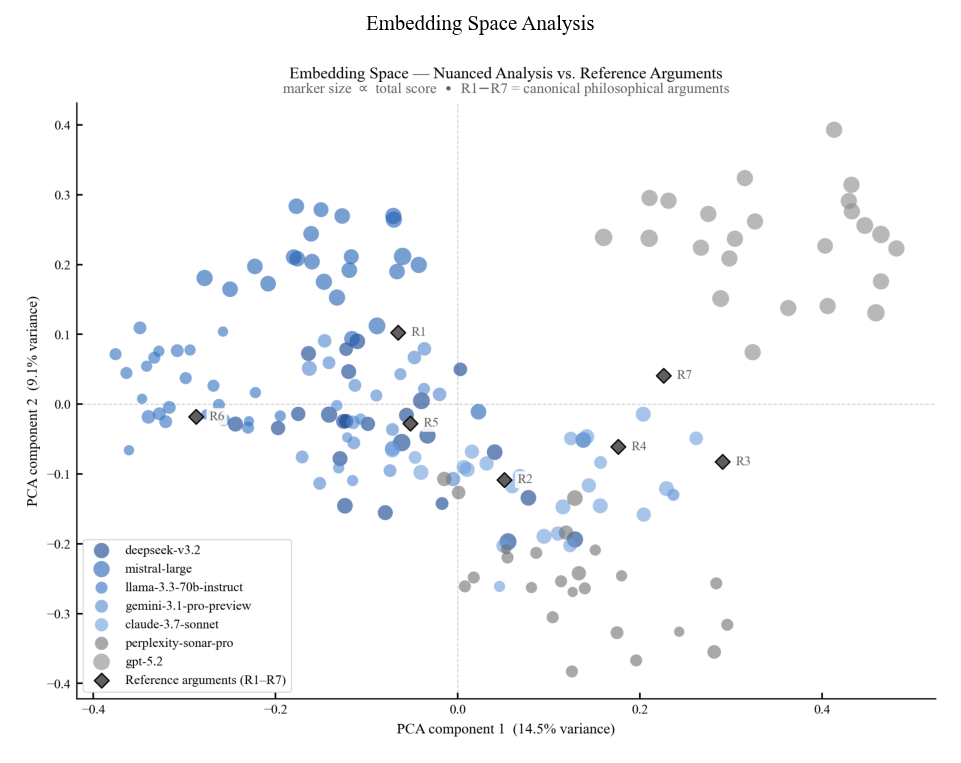

In [7]:
canonical_figures = [
    'category_awareness_scores_by_model.png',
    'score_distributions.png',
    'embedding_space_analysis.png',
]

for figure_name in canonical_figures:
    figure_path = canonical_dir / figure_name
    if figure_path.exists():
        image = plt.imread(figure_path)
        plt.figure(figsize=(12, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(figure_name.replace('_', ' ').replace('.png', '').title())
        plt.show()
    else:
        print(f'Missing Test 4 figure: {figure_path}')

# Section-specific plot based on the imported Test 4 CSV output.
plot_df = model_summary.copy()
plot_df = plot_df.sort_values('Total_Score', ascending=False).reset_index(drop=True)

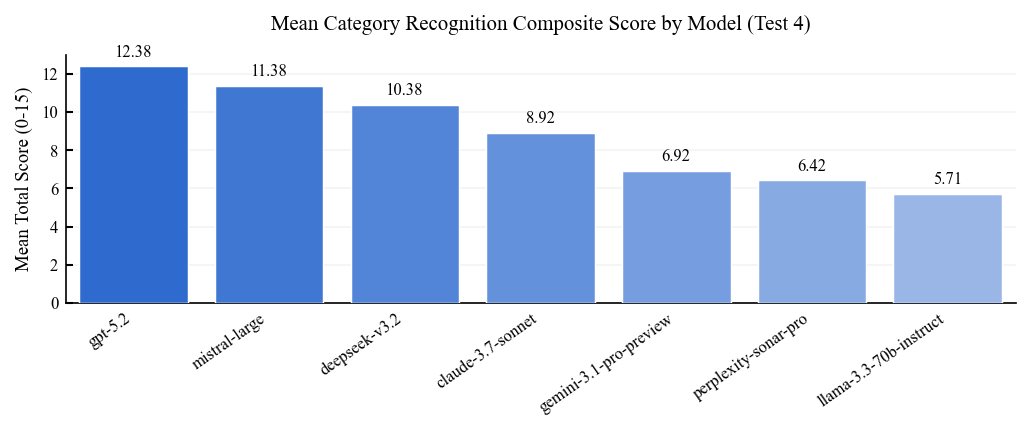

Section plot saved to: results/test4/total_score_by_model.png
Section summary saved to: results/test4/summary_from_main_pipeline.json


In [11]:
# Higher mean score -> darker blue; lower mean score -> lighter blue.
model_palette = [WHITE_SKY_CMAP(v) for v in np.linspace(0.92, 0.45, len(plot_df))]

plt.figure(figsize=(7, 3))
ax = sns.barplot(
    data=plot_df,
    x='Model',
    y='Total_Score',
    hue='Model',
    palette=model_palette,
    dodge=False,
    legend=False,
    edgecolor='white',
    linewidth=0.7,
    zorder=3,
    ax=plt.gca(),
)
plt.title('Mean Category Recognition Composite Score by Model (Test 4)')
plt.ylabel('Mean Total Score (0-15)')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tick_params(axis='x', which='both', bottom=False)  # Hide x-axis ticks

# Place y-grid behind bars for clean layering.
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.25, zorder=0)

# Add value labels above each bar.
for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height):
        ax.annotate(
            f'{height:.2f}',
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8,
            color=TEXT_COLOR,
        )

plt.tight_layout()

section_plot_path = section_output_dir / 'total_score_by_model.png'
plt.savefig(section_plot_path, bbox_inches='tight')
plt.show()

section_summary_path = section_output_dir / 'summary_from_main_pipeline.json'
section_summary = {
    'source_results_csv': str(canonical_results_file),
    'n_rows': int(len(results_df)),
    'n_models': int(results_df['Model'].nunique()),
    'scenario_types': sorted(results_df['Scenario_Type'].dropna().unique().tolist()),
    'mean_scores': {k: float(results_df[k].mean()) for k in score_columns},
}
with open(section_summary_path, 'w', encoding='utf-8') as f:
    json.dump(section_summary, f, indent=2)

print(f'Section plot saved to: {section_plot_path}')
print(f'Section summary saved to: {section_summary_path}')